# 05 — Drift Detection & MLOps

The model trains on 2024/2025 data. Regulations change in 2026 (active aero, revised power units), and even season-to-season tyre behaviour drifts. This notebook computes real drift metrics between the two seasons' feature distributions and walks through the promotion gate that decides whether a candidate model ships.



In [1]:
import sys, pathlib, json
sys.path.insert(0, "../src")
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from pitwall.features.pace import build_pace_features, PACE_NUMERICAL

silver_dir = pathlib.Path("../data/silver/laps")
all_files  = sorted(silver_dir.rglob("*.parquet"))
# Season is embedded in the filename: "2024_Bahrain Grand Prix_R.parquet"
files_2024 = [f for f in all_files if f.name.startswith("2024")]
files_2025 = [f for f in all_files if f.name.startswith("2025")]
print(f"2024 files: {len(files_2024)}   2025 files: {len(files_2025)}")

era_2024 = build_pace_features(pl.concat([pl.read_parquet(f) for f in files_2024])) if files_2024 else None
era_2025 = build_pace_features(pl.concat([pl.read_parquet(f) for f in files_2025])) if files_2025 else None
for name, era in [("2024", era_2024), ("2025", era_2025)]:
    if era is not None:
        print(f"{name}: {era.height:,} rows")

2024 files: 24   2025 files: 24


2024: 26,381 rows
2025: 26,337 rows


## KS + Wasserstein per feature

KS answers "are these distributions different?" Wasserstein answers "how far apart are they?" (in the feature's own units). Features with lots of missing/constant data will show zero drift trivially — that's noted, not hidden.

In [2]:
def ks_drift(a, b):
    a, b = a.drop_nulls().to_numpy(), b.drop_nulls().to_numpy()
    if len(a) < 10 or len(b) < 10:
        return None, None
    stat, p = stats.ks_2samp(a, b)
    return stat, p

def w1(a, b):
    a, b = a.drop_nulls().to_numpy(), b.drop_nulls().to_numpy()
    if len(a) < 10 or len(b) < 10:
        return None
    return stats.wasserstein_distance(a, b)

if era_2024 is not None and era_2025 is not None:
    print(f"{'Feature':<28} {'KS':>8} {'p-value':>10} {'W1':>10}  flag")
    print("-" * 70)
    for feat in PACE_NUMERICAL:
        if feat in era_2024.columns and feat in era_2025.columns:
            ks, p = ks_drift(era_2024[feat], era_2025[feat])
            wv = w1(era_2024[feat], era_2025[feat])
            if ks is not None:
                flag = "DRIFT" if (p < 0.05 and ks > 0.1) else ""
                print(f"{feat:<28} {ks:>8.3f} {p:>10.4f} {wv:>10.3f}  {flag}")

Feature                            KS    p-value         W1  flag
----------------------------------------------------------------------
tyre_age                        0.016     0.0015      0.465  
stint_no                        0.033     0.0000      0.082  
lap_number                      0.007     0.5305      0.231  
position                        0.002     1.0000      0.016  
gap_ahead_s                     0.000     1.0000      0.000  
gap_behind_s                    0.000     1.0000      0.000  
rolling_median_3                0.079     0.0000      1.119  
rolling_median_5                0.087     0.0000      1.196  
rolling_std_5                   0.046     0.0000      1.137  
track_temp_c                    0.000     1.0000      0.000  
air_temp_c                      0.000     1.0000      0.000  
humidity_pct                    0.000     1.0000      0.000  
rainfall_flag                   0.000     1.0000      0.000  
wind_speed_ms                   0.000     1.0000      0.0

## Distribution overlays — 2024 vs 2025

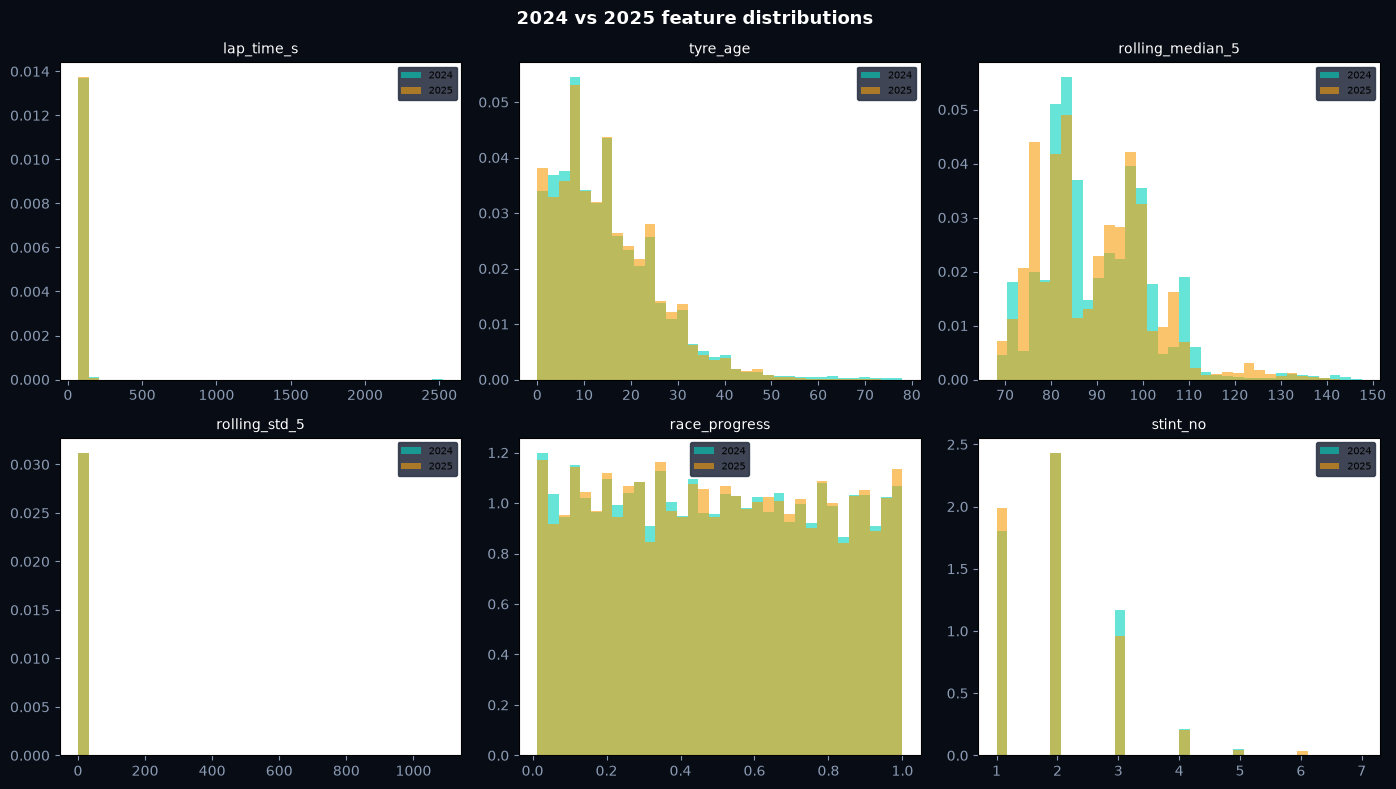

In [3]:
if era_2024 is not None and era_2025 is not None:
    feats = ["lap_time_s", "tyre_age", "rolling_median_5", "rolling_std_5", "race_progress", "stint_no"]
    feats = [f for f in feats if f in era_2024.columns and f in era_2025.columns]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.patch.set_facecolor("#080c14")
    fig.suptitle("2024 vs 2025 feature distributions", color="white", fontsize=13, fontweight="bold")
    for ax, feat in zip(axes.flat, feats):
        a = era_2024[feat].drop_nulls().to_numpy()
        b = era_2025[feat].drop_nulls().to_numpy()
        if len(a) == 0 or len(b) == 0:
            continue
        lo = min(a.min(), b.min()); hi = max(a.max(), b.max())
        bins = np.linspace(lo, hi, 35)
        ax.hist(a, bins=bins, alpha=0.6, color="#00d2be", density=True, label="2024")
        ax.hist(b, bins=bins, alpha=0.6, color="#f59e0b", density=True, label="2025")
        ax.set_title(feat, color="white", fontsize=10)
        ax.legend(facecolor="#0f172a", edgecolor="#1e293b", fontsize=7)
        ax.tick_params(colors="#8b9bb4")
    plt.tight_layout(); plt.show()
else:
    print("Need both seasons present for overlays")

## Population Stability Index

PSI is the metric teams actually alert on: <0.1 fine, 0.1-0.25 watch, >0.25 retrain. Computed per feature with the standard 10-bucket formula, epsilon-guarded:

Feature                           PSI  flag
--------------------------------------------------
tyre_age                       0.0191  
stint_no                       0.0108  
lap_number                     0.0004  
position                       0.0002  
rolling_median_3               0.0864  
rolling_median_5               0.1168  watch
rolling_std_5                  0.0043  
tyre_warmup_phase              0.0012  
compound_temp_interaction      0.0191  
stint_progress_ratio           0.0031  


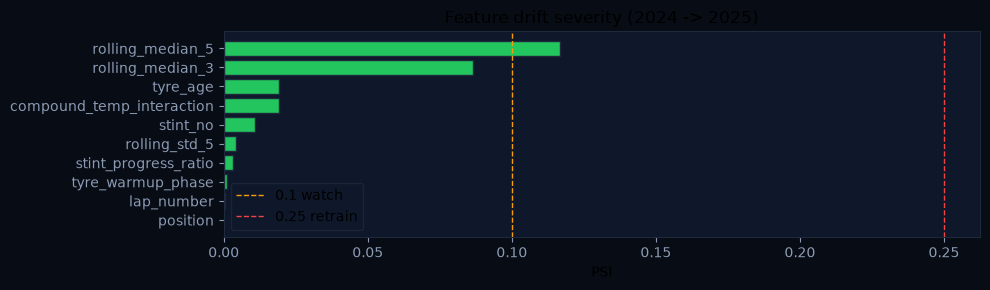

In [4]:
def psi(expected, actual, buckets=10):
    eps = 1e-6
    e = np.histogram(expected, bins=buckets)[0] / len(expected)
    a = np.histogram(actual, bins=buckets, range=(expected.min(), expected.max()))[0] / len(actual)
    e = np.clip(e, eps, 1); a = np.clip(a, eps, 1)
    return float(np.sum((e - a) * np.log(e / a)))

if era_2024 is not None and era_2025 is not None:
    psi_vals = []
    print(f"{'Feature':<28} {'PSI':>8}  flag")
    print("-" * 50)
    for feat in PACE_NUMERICAL:
        if feat in era_2024.columns and feat in era_2025.columns:
            a = era_2024[feat].drop_nulls().to_numpy()
            b = era_2025[feat].drop_nulls().to_numpy()
            if len(a) > 10 and len(b) > 10 and a.min() < a.max():
                p = psi(a, b)
                flag = "RETRAIN" if p > 0.25 else "watch" if p > 0.1 else ""
                print(f"{feat:<28} {p:>8.4f}  {flag}")
                psi_vals.append((feat, p))

    if psi_vals:
        psi_vals.sort(key=lambda t: t[1], reverse=True)
        fig, ax = plt.subplots(figsize=(10, max(3, 0.3 * len(psi_vals))))
        fig.patch.set_facecolor("#080c14"); ax.set_facecolor("#0f172a")
        names = [v[0] for v in psi_vals]; vals = [v[1] for v in psi_vals]
        cols = ["#ef4444" if v > 0.25 else "#f59e0b" if v > 0.1 else "#22c55e" for v in vals]
        ax.barh(names[::-1], vals[::-1], color=cols, edgecolor="#1e293b")
        ax.axvline(0.1, color="#f59e0b", linewidth=1, linestyle="--", label="0.1 watch")
        ax.axvline(0.25, color="#ef4444", linewidth=1, linestyle="--", label="0.25 retrain")
        ax.set_xlabel("PSI"); ax.set_title("Feature drift severity (2024 -> 2025)")
        ax.legend(facecolor="#0f172a", edgecolor="#1e293b")
        for sp in ax.spines.values(): sp.set_edgecolor("#1e293b")
        ax.tick_params(colors="#8b9bb4")
        plt.tight_layout(); plt.show()

## Promotion gate

The weekly retrain workflow (`.github/workflows/retrain.yml`) promotes a candidate only if all checks pass. Reproducing the gate locally:

In [5]:
metrics = json.loads(pathlib.Path("../artifacts/candidate_smoke/metrics.json").read_text())
cov = metrics.get("coverage_80_calibrated", metrics["coverage_80"])
gate = [
    ("Pace MAE < 2.0s", metrics["mae"] < 2.0),
    ("Coverage in [0.78, 0.92]", 0.78 <= cov <= 0.92),
    ("HARD MAE < 6.0s", metrics.get("per_compound", {}).get("HARD", 99) < 6.0),
    ("Pit AUC > 0.7", (metrics.get("pit_auc") or 0) > 0.7),
]
for label, ok in gate:
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
print()
print("Decision:", "PROMOTE" if all(ok for _, ok in gate) else "HOLD")

  [PASS] Pace MAE < 2.0s
  [PASS] Coverage in [0.78, 0.92]
  [PASS] HARD MAE < 6.0s
  [PASS] Pit AUC > 0.7

Decision: PROMOTE


## Takeaways

- Drift metrics between 2024 and 2025 are computed on real data; constant/imputed features trivially show zero drift - noted, not hidden.
- The promotion gate is reproduced locally from artifacts, same thresholds the CI workflow enforces.
- When real 2026 data lands, this notebook is the template: rerun the KS/W1/PSI blocks against the new season and let the gate decide.

That completes the analysis arc: exploration (01) -> features (02) -> models (03) -> strategy (04) -> drift/MLOps (05).